# Selected Statistics for the Largest Public School Districts

This dataset includes data on the 50 largest districts by enrollment size.
It includes the district name, city, state, county as qualiatative values.
It includes number of students, teachers, completers, and schools as quantatiative values.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
# Might be relevant for some commands
print(f"Pandas Version: {pd.__version__}")

Pandas Version: 3.0.1


In [3]:
df = pd.read_csv(
    "../datasets/245 - Selected Statistics for the Largest Public School Districts.tsv",
    sep="\t",
)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 8 columns):
 #   Column                                         Non-Null Count  Dtype
---  ------                                         --------------  -----
 0   School district                                50 non-null     str  
 1   City                                           50 non-null     str  
 2   State                                          50 non-null     str  
 3   County                                         50 non-null     str  
 4   Number of students                             50 non-null     str  
 5   Number of full-time equivalent (FTE) teachers  50 non-null     str  
 6   Number of 2006-07 completers                   50 non-null     str  
 7   Number of schools                              50 non-null     str  
dtypes: str(8)
memory usage: 3.3 KB


In [5]:
df.replace(",", "", regex=True, inplace=True)

,School district,City,State,County,Number of students,Number of full-time equivalent (FTE) teachers,Number of 2006-07 completers,Number of schools
0,New York City Public Schools NY,New York,NY,New York,981690,71824,49978,1436
1,Los Angeles Unified CA,Los Angeles,CA,Los Angeles,687534,35084,27004,860
2,City of Chicago School District IL,Chicago,IL,Cook,421430,21512,18263,630
3,Dade County School District FL,Miami,FL,Miami-Dade,345525,22384,18030,496
4,Clark County School District NV,Las Vegas,NV,Clark,312761,15348,10943,350
5,Broward County School District FL,Fort Lauderdale,FL,Broward,256351,18729,14201,303
6,Houston Independent School District TX,Houston,TX,Harris,200225,11994,7645,296
7,Hillsborough County School District FL,Tampa,FL,Hillsborough,192007,13986,9858,285
8,Hawaii Department of Education HI,Honolulu,HI,Honolulu,179478,11294,11063,290
9,Orange County School District FL,Orlando,FL,Orange,172257,10975,9178,236


In [6]:
numeric_cols = [
    "Number of students",
    "Number of full-time equivalent (FTE) teachers",
    "Number of 2006-07 completers",
    "Number of schools",
]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric)

## Number of Students per School

In [7]:
df["Number of Students Per School"] = df["Number of students"] / df["Number of schools"]

In [8]:
group = df.groupby("State")["Number of Students Per School"].mean().reset_index()

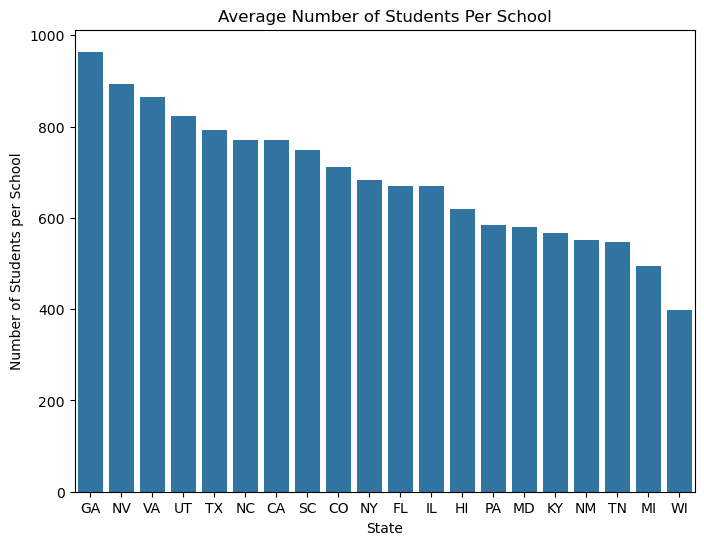

In [9]:
plt.figure(figsize=(8, 6))
sns.barplot(
    x="State",
    y="Number of Students Per School",
    data=group.sort_values("Number of Students Per School", ascending=False),
)
plt.title("Average Number of Students Per School")
plt.xlabel("State")
plt.ylabel("Number of Students per School")

plt.savefig("avg_stud_per_scho.png", dpi=300)
plt.show()